# Entity Resolution: поиск и объединение дубликатов профилей

**Кейс:** определить, какие профили (`profile_id`) относятся к одному реальному человеку (`entity_id`),
и предложить их автоматическое / полуавтоматическое объединение по неполным и зашумлённым данным.

Это исправленная и дополненная версия исходного решения.

## Что было не так и что исправлено

**Критичные (из-за них метрики были завышены):**
1. **Сплит по парам, а не по сущностям.** `train_test_split` по парам → утечка: один `entity_id` попадал и в train,
   и в validation, модель «узнавала» ответ. → **Сплит по `entity_id`** (все пары сущности в одном фолде).
2. **«Лёгкие» негативы.** Негативы собирались как случайные пары внутри домена — они почти ничего не разделяют,
   задача становилась тривиальной, метрики — нереалистично высокими. → **Hard-негативы из того же блокинга**,
   что и на инференсе (реалистичный дисбаланс классов).
3. **Шум разметки негативов.** Случайная пара внутри домена могла оказаться настоящим дублем (метка 0 ошибочна).

**Корректность данных:**
4. **Профиль встречается в нескольких строках-событиях, а база не схлопывалась.** `groupby(...).tolist()` давал
   самопары `(A,A)` и дубли пар; `merge` по `profile_id` «размножал» строки. → **Схлопывание в 1 строку на профиль**.
5. **Парсинг массивов молча ломался.** Формат `['a:b' 'c:d']` (repr numpy-массива, токены через пробел)
   `ast.literal_eval` склеивает в один ключ. На parquet работало, на CSV — нет. → **Надёжный токенайзер**.

**Методология (главное замечание про блокинг):**
6. **Блокинг только по домену email теряет дубли.** Домен сохраняется при анонимизации, но человек заводит
   профили на gmail и mail.ru → такие пары никогда не сравниваются. Ниже это показано численно (теряется ~40%).
   → **Мульти-ключевой блокинг**: домен + телефон + имя/гео + **поведенческий по общим site-id** (домен-независимый).

**Баги и устойчивость:**
7. `task_type='GPU'` падал без GPU → **`'CPU'`** (переключается одной строкой).
8. **Сломанная SHAP-визуализация:** `shap.plots.waterfall(..., show=False)` создаёт свою фигуру и игнорирует
   подготовленные `ax`/`gridspec`. → **Перерисовано вручную** на контролируемых осях.
9. Прочее: повторный пересчёт `cluster_sizes`; защита от отсутствующих колонок; **два порога** —
   авто-объединение (высокая precision) и ручная проверка.

> **Про данные.** Реальный `split_label_train_V3.snappy.parquet` в окружение не передавался, поэтому ноутбук
> по умолчанию генерирует **синтетический датасет той же схемы** (грязный строковый формат массивов,
> кросс-доменные дубли, общие site-id), чтобы всё исполнялось и рисовалось. Для работы с настоящими данными
> задайте `DATA_PATH` в ячейке загрузки — код сам подхватит parquet, остальное менять не нужно.

In [1]:
 !pip install -q catboost shap networkx pyarrow   # для Colab раскомментируйте
import pandas as pd, numpy as np
import ast, json, re, random, itertools, gc, time
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Загрузка данных

Ноутбук пробует прочитать ваш parquet; если файла нет — строит синтетику той же схемы.

In [2]:
DATA_PATH = 'split_label_train_V3.snappy.parquet'   # <-- путь к вашему parquet
try:
    df = pd.read_parquet(DATA_PATH); print(f"Загружен реальный датасет: {df.shape}")
except Exception as e:
    print("No data")
df.head(3)

Загружен реальный датасет: (68036, 12)


,created_at,first_name,last_name,email,phone,birthday,sex,non_processing_features,realtime_features,fs_features,profile_id,entity_id
0,2025-11-01 00:27:04.995,Анфиса,None,lqvxvltxx@mail.ru,None,None,female,"[device:smartphone, geoname_id:2013348, browser:chrome, osfamily:android, su...","{""country"":""RU"",""is_million"":false,""tz_offset"":10,""geoname"":""Vladivostok"",""g...","[visited_30:250, visited_365:1813, visited_30:1805]",b25135c7-b4f8-3552-8eb6-46331ceea5c9,7266581b455c33f90f4e2418ab7d12e3ec704935338ecf828f6621b6b68a8da9
1,2025-11-01 00:38:35.323,Надежда,None,kstpnq.6751@mail.ru,None,None,female,"[device:smartphone, geoname_id:2025339, browser:yandex, subdivision_1_iso_co...","{""country"":""RU"",""is_million"":false,""tz_offset"":9,""geoname"":""Chita"",""geoid"":2...",[source_site_365:6370],2403b42b-2420-35c2-ac8e-e6572c2920f6,bd0dc28d66040e40ad5303a3ed8f3988973726bb3d03075777796427ff325c4e
2,2025-11-01 00:47:20.741,None,None,vsima16wnf@mail.ru,None,None,female,"[device:smartphone, subdivision_1_iso_code:SAM, osfamily:android, geoname_id...","{""country"":""RU"",""is_million"":true,""tz_offset"":4,""geoname"":""Samara"",""geoid"":4...","[has_account:1345, source_site_365:4253, has_click_365:3448, has_account:278...",866e538b-a451-32a1-8b2d-06cb3c5ec71b,6f2ff507f07d2563b592bd399e193cae866ea4144a261f59012996ed35f08a71


## 2. Парсинг вложенных полей (надёжный)

`non_processing_features` и `fs_features` — это `array<string>`. В parquet это настоящие массивы, но в выгрузке/CSV —
строка вида `['a:b' 'c:d']` (repr numpy-массива, **токены через пробел, без запятых**). Старый `ast.literal_eval`
на такой строке молча склеивал всё в один ключ. Парсер ниже работает в обоих случаях.

In [3]:
_TOKEN_RE = re.compile(r"'([^']*)'|\"([^\"]*)\"")
def _coerce_to_list(s):
    if isinstance(s,(list,tuple,np.ndarray)): return [x for x in s if isinstance(x,str)]
    if isinstance(s,str):
        st=s.strip()
        if st in ('','[]','{}'): return []
        if st.startswith('['):
            toks=[a or b for a,b in _TOKEN_RE.findall(st)]
            if toks: return toks
            try:
                v=ast.literal_eval(st); return [x for x in v if isinstance(x,str)] if isinstance(v,list) else []
            except (ValueError,SyntaxError): return []
    return []
def parse_kv_list_to_dict(s, handle_duplicates=True, sep='|'):
    res={}
    for item in _coerce_to_list(s):
        k,v=(item.split(':',1) if ':' in item else (item,True))
        if k in res:
            if handle_duplicates: res[k]=f"{res[k]}{sep}{v}"
        else: res[k]=v
    return res
def parse_json_to_dict(s):
    if isinstance(s,dict): return s
    if isinstance(s,str):
        st=s.strip()
        if st in ('','{}'): return {}
        try:
            r=json.loads(st); return r if isinstance(r,dict) else {}
        except (ValueError,json.JSONDecodeError): return {}
    return {}

assert parse_kv_list_to_dict("['source_site_365:6307' 'has_click_365:6880' 'is_gmail']") == \
       {'source_site_365':'6307','has_click_365':'6880','is_gmail':True}
print("Парсер OK (корректно разбирает строковый repr массива)")

Парсер OK (корректно разбирает строковый repr массива)


In [4]:
print("Разворачиваем вложенные поля в плоские колонки...")
np_df = pd.json_normalize(df['non_processing_features'].apply(lambda x: parse_kv_list_to_dict(x, handle_duplicates=False))).add_prefix('np_')
rt_df = pd.json_normalize(df['realtime_features'].apply(parse_json_to_dict)).add_prefix('rt_')
fs_df = pd.json_normalize(df['fs_features'].apply(lambda x: parse_kv_list_to_dict(x, True, '|'))).add_prefix('fs_')
base = df.drop(columns=['non_processing_features','realtime_features','fs_features']).reset_index(drop=True)
df_flat = pd.concat([base, np_df.reset_index(drop=True), rt_df.reset_index(drop=True), fs_df.reset_index(drop=True)], axis=1)
df_flat['created_at'] = pd.to_datetime(df_flat['created_at'], errors='coerce')
print(f"Готово: {df_flat.shape[0]} строк-событий, {df_flat.shape[1]} колонок")
df_flat.sample(3)

del df; gc.collect()

Разворачиваем вложенные поля в плоские колонки...
Готово: 68036 строк-событий, 52 колонок


30

In [5]:
df_flat.sample(3)

,created_at,first_name,last_name,email,phone,birthday,sex,profile_id,entity_id,np_device,np_geoname_id,np_browser,np_osfamily,np_subdivision_1_iso_code,np_is_not_russia,rt_country,rt_is_million,rt_tz_offset,rt_geoname,rt_geoid,rt_local_hour,rt_day,rt_population,rt_visit_count,fs_visited_30,fs_visited_365,fs_source_site_365,fs_has_account,fs_has_click_365,fs_has_accept_365,fs_is_phone,fs_has_order_30,fs_is_man,fs_has_order_365,fs_is_woman,fs_is_gmail,fs_source_site_30,fs_has_click_30,fs_has_accept_30,fs_is_yandex,fs_was_phone_lead,fs_mm_event_30,fs_mm_event_90,fs_postman_response_30,fs_postman_action_30,fs_postman_campaign_30,fs_postman_campaign_90,fs_postman_action_90,fs_postman_response_90,fs_postman_scenario_30,fs_postman_scenario_90,fs_has_view_90
34242,2026-02-19 16:27:33.726,None,None,fuwti6488@yandex.ru,None,None,unknown,b0a5ce9e-a91c-39bf-b886-aa78c8229e5a,8e3f14c7a1ae717aa119643dc509043849399c0d8e97450606688605717abbe8,smartphone,538560,chrome,android,KRS,NaN,RU,False,3.0,Kursk,538560.0,19.0,3.0,448733.0,NaN,1345,NaN,6659|1747|3775|4211,3679|4880|1345|899|3210,6297|6941|3684|5506|6184|3824|6375,3684|5506|4049|6941|3824|6184|6375,NaN,NaN,True,NaN,True,True,6659|4211,5506|3684|3824|6941,6941|3824|5506|3684|4049,True,NaN,sent,sent,ok,smtp_sent,exchange,exchange,smtp_sent,ok,NaN,NaN,NaN
10007,2025-12-14 03:36:33.149,None,None,lelxbkehjp@bk.ru,None,None,unknown,836a1496-803a-3765-8a80-45623b331a7a,f015f0679118a5bd2746603a4e0af413970a634cf24f86330d5dda171d7b8c2c,smartphone,NaN,NaN,ios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66182,2026-05-06 01:44:29.535,None,None,rmlhmkdyjmcrs60@mail.ru,None,None,unknown,ee56c2f2-508f-34d1-b686-139b4959d07e,5c738e4d7ddd0cc9163b505d514a041597f5dbb1eba7324bac265a06859a2ff0,smartphone,1498894,NaN,android,CHE,NaN,RU,False,5.0,Miass,1498894.0,6.0,2.0,167500.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. EDA: разреженность PII и паттерны дублей

Целевая разметка — `entity_id`. Тип сущности (`single`/`multi`) считаем по числу уникальных профилей на сущность.

In [6]:
# тип сущности по числу уникальных профилей (а НЕ по числу строк-событий)
prof_per_entity = df_flat.groupby('entity_id')['profile_id'].nunique()
df_flat['entity_type'] = df_flat['entity_id'].map(
    prof_per_entity.apply(lambda x: 'multi_profile' if x > 1 else 'single_profile'))

n_prof = df_flat['profile_id'].nunique()
n_ent  = df_flat['entity_id'].nunique()
n_multi = (prof_per_entity > 1).sum()
print(f"Уникальных профилей: {n_prof}")
print(f"Уникальных сущностей (людей): {n_ent}")
print(f"Сущностей-дублей (multi_profile): {n_multi} ({n_multi/n_ent*100:.1f}%)")

Уникальных профилей: 61927
Уникальных сущностей (людей): 53369
Сущностей-дублей (multi_profile): 8073 (15.1%)


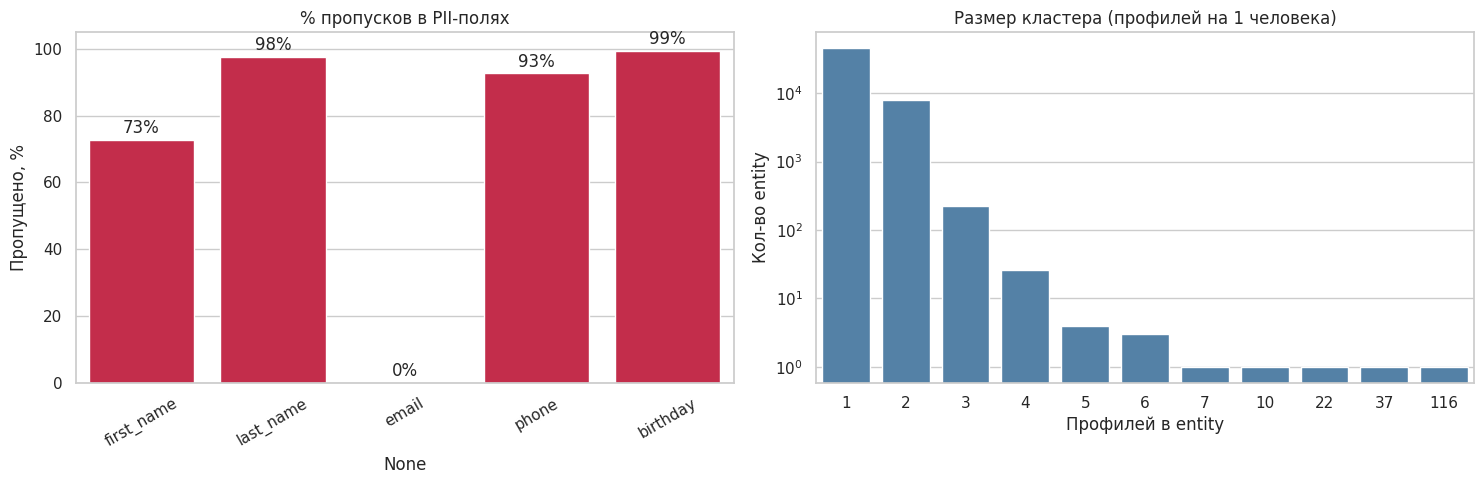

Вывод: ФИО/телефон/др. сильно разрежены — точный матч по ним покроет малую долю дублей.
Нужны поведенческие признаки (общие site-id) и метрики сходства, а не равенство.


In [7]:
# Разреженность PII + распределение размеров кластеров
pii_cols = [c for c in ['first_name','last_name','email','phone','birthday'] if c in df_flat.columns]
missing = df_flat[pii_cols].isnull().mean()*100

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=missing.index, y=missing.values, ax=ax[0], color='crimson')
ax[0].set_title('% пропусков в PII-полях'); ax[0].set_ylabel('Пропущено, %'); ax[0].set_ylim(0,105)
ax[0].tick_params(axis='x', rotation=30)
for i,v in enumerate(missing.values): ax[0].text(i, v+2, f"{v:.0f}%", ha='center')

sizes = prof_per_entity.value_counts().sort_index()
sns.barplot(x=sizes.index.astype(int), y=sizes.values, ax=ax[1], color='steelblue')
ax[1].set_title('Размер кластера (профилей на 1 человека)')
ax[1].set_xlabel('Профилей в entity'); ax[1].set_ylabel('Кол-во entity'); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()
print("Вывод: ФИО/телефон/др. сильно разрежены — точный матч по ним покроет малую долю дублей.")
print("Нужны поведенческие признаки (общие site-id) и метрики сходства, а не равенство.")

### 3.1 Ключевой вопрос: можно ли блокировать только по домену email?

Замечание из ТЗ верное: **нет**. Домен при анонимизации сохраняется, но человек регистрируется на разных
почтовых провайдерах. Посмотрим, у скольких реальных людей (`multi_profile`) встречается более одного домена.

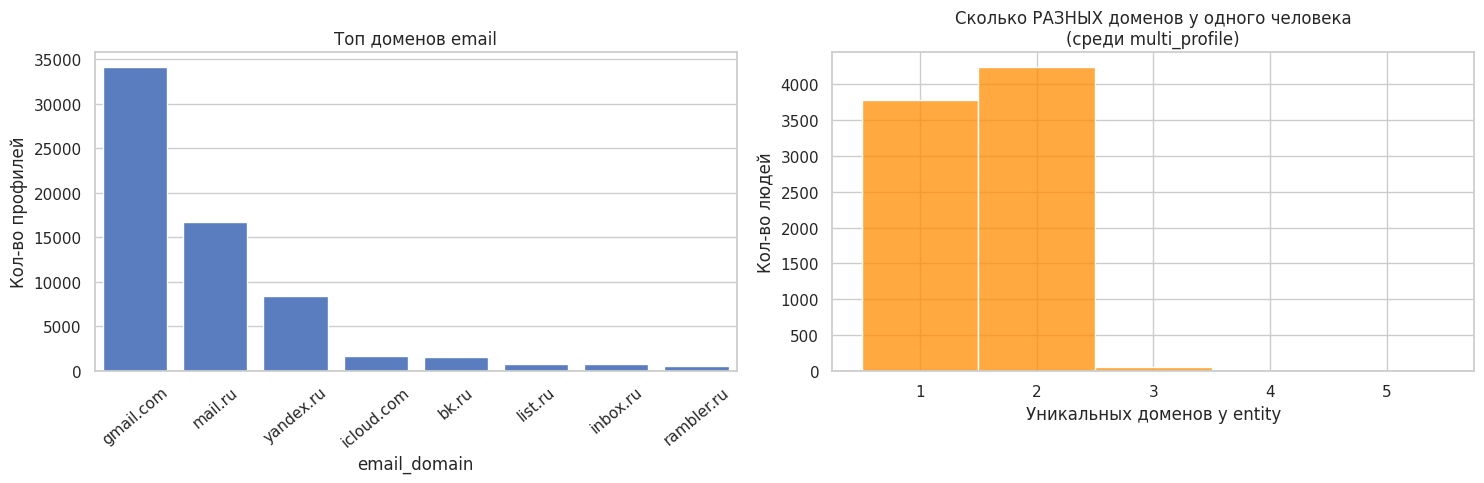

Доля multi_profile-людей с >1 доменом email: 53.2%
=> Блокинг ТОЛЬКО по домену структурно НЕ найдёт эти дубли. Нужны домен-независимые ключи.


In [8]:
df_flat['email_domain'] = df_flat['email'].astype('string').str.split('@').str[-1]
multi_ids = prof_per_entity[prof_per_entity > 1].index
dom_per_entity = df_flat[df_flat['entity_id'].isin(multi_ids)].groupby('entity_id')['email_domain'].nunique()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
top = df_flat['email_domain'].value_counts().head(8)
sns.barplot(x=top.index, y=top.values, ax=ax[0]); ax[0].set_title('Топ доменов email')
ax[0].tick_params(axis='x', rotation=40); ax[0].set_ylabel('Кол-во профилей')

sns.histplot(dom_per_entity, discrete=True, ax=ax[1], color='darkorange')
ax[1].set_title('Сколько РАЗНЫХ доменов у одного человека\n(среди multi_profile)')
ax[1].set_xlabel('Уникальных доменов у entity'); ax[1].set_ylabel('Кол-во людей')
plt.tight_layout(); plt.show()

share = (dom_per_entity > 1).mean()*100
print(f"Доля multi_profile-людей с >1 доменом email: {share:.1f}%")
print("=> Блокинг ТОЛЬКО по домену структурно НЕ найдёт эти дубли. Нужны домен-независимые ключи.")

## 4. Схлопывание событий в профили

Одна строка = событие, профиль может встречаться многократно. Для матчинга нужна **одна строка на профиль**:
берём последнее событие для скалярных полей и **объединяем все site-id** из `fs_*` по всем событиям профиля.
Это убирает самопары `(A,A)` и «размножение» строк при merge.

In [9]:
SITE_SET_COLS = ['fs_visited_30','fs_visited_365','fs_source_site_365','fs_has_account',
                 'fs_has_click_365','fs_has_accept_365','fs_has_order_30','fs_has_order_365',
                 'fs_source_site_30','fs_has_click_30','fs_has_accept_30','fs_has_view_90']

def collapse_to_profiles(flat):
    flat = flat.sort_values('created_at')
    present = [c for c in SITE_SET_COLS if c in flat.columns]
    union = {c: defaultdict(set) for c in present}
    for c in present:
        sub = flat[['profile_id', c]].dropna(subset=[c])
        for pid, val in zip(sub['profile_id'].values, sub[c].values):
            if isinstance(val, str) and val:
                union[c][pid].update(val.split('|'))
    prof = flat.groupby('profile_id', as_index=False).last()
    for c in present:
        prof[c] = prof['profile_id'].map(lambda p: frozenset(union[c].get(p, set())) or None)
    prof['email_domain'] = prof['email'].astype('string').str.split('@').str[-1]
    return prof

prof = collapse_to_profiles(df_flat)
print(f"Профилей после схлопывания: {len(prof)} | дублей profile_id: {prof['profile_id'].duplicated().sum()}")

del df_flat; gc.collect()

Профилей после схлопывания: 61927 | дублей profile_id: 0


33

In [10]:
prof.sample(3)

,profile_id,created_at,first_name,last_name,email,phone,birthday,sex,entity_id,np_device,np_geoname_id,np_browser,np_osfamily,np_subdivision_1_iso_code,np_is_not_russia,rt_country,rt_is_million,rt_tz_offset,rt_geoname,rt_geoid,rt_local_hour,rt_day,rt_population,rt_visit_count,fs_visited_30,fs_visited_365,fs_source_site_365,fs_has_account,fs_has_click_365,fs_has_accept_365,fs_is_phone,fs_has_order_30,fs_is_man,fs_has_order_365,fs_is_woman,fs_is_gmail,fs_source_site_30,fs_has_click_30,fs_has_accept_30,fs_is_yandex,fs_was_phone_lead,fs_mm_event_30,fs_mm_event_90,fs_postman_response_30,fs_postman_action_30,fs_postman_campaign_30,fs_postman_campaign_90,fs_postman_action_90,fs_postman_response_90,fs_postman_scenario_30,fs_postman_scenario_90,fs_has_view_90,entity_type,email_domain
45247,bad6068b-a69a-39c4-849a-1e604c75775b,2026-03-09 10:55:45.914,None,None,wwgeiyowtdh17@bk.ru,None,None,male,c6356d4c4307a6f3adf055874966dce70aa2e70f402369af33da80682659445c,smartphone,2759794,None,ios,NH,True,NL,False,1.0,Amsterdam,2759794.0,11.0,0.0,741636.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,single_profile,bk.ru
24382,640cc05e-103e-3dbc-968b-69adf44c4515,2025-12-27 11:44:43.978,None,None,uzgnqqk.s@inbox.ru,None,None,unknown,246232bafecd5bc7703714539088e96d40f1fd3e094396a4fd00bbab020350f0,pc,523064,chrome,windows,IN,None,RU,False,3.0,Nazran,523064.0,14.0,5.0,164131.0,None,None,(2275),(4021),"(3210, 1345)","(3218, 3322, 3684, 3741, 3392)","(3218, 3322, 3684, 3715, 3741, 6375, 5231)",None,None,None,None,None,None,None,None,None,None,None,sent,sent,None,None,None,exchange,smtp_sent,ok,None,None,None,multi_profile,inbox.ru
18481,4bc88560-285e-3d39-84db-dccc099113cb,2025-11-21 05:16:03.363,None,None,tfezyk.wfycrvzrm4309@gmail.com,None,None,unknown,4050afab98b1055ba7213728d14710bb9a115295c088bf914b4fee4344105587,smartphone,None,None,ios,None,True,None,None,NaN,None,NaN,NaN,NaN,NaN,None,(1345),None,(6329),"(250, 1345)","(3684, 3827)","(3684, 3827)",None,None,None,None,True,True,(6329),"(3684, 3827)","(3684, 3827)",None,None,None,None,None,None,None,None,None,None,None,None,None,multi_profile,gmail.com


## 5. Мульти-ключевой блокинг (с поведенческим ключом)

Сравнивать все пары нельзя (≈ N²/2). Блокинг отбирает кандидатов. Используем **несколько ключей** и берём
**объединение** пар:

- `dom::<домен>` — дёшево, но не ловит кросс-доменные дубли;
- `phone::<телефон>` — сильный, но редкий;
- `name::<имя>::<geoid>` — для заполненных ФИО;
- **`site::<site_id>` — инвертированный индекс по объединению всех `fs_*`.** Это домен-независимый ключ:
  если два профиля заходили на один и тот же замаскированный site_id — они кандидаты, даже если домены разные.

Слишком частые site-id (стоп-слова) и гигантские блоки контролируем порогами/сэмплированием.
Качество блокинга меряем **blocking recall** — долей истинных пар-дублей, попавших в кандидаты (это потолок recall системы).

In [11]:
def build_blocks(prof, max_block=300, site_stop_min_df=150, rng=None):
    rng = rng or np.random.default_rng(0)
    blocks = defaultdict(list); cols = prof.columns
    site_cols = [c for c in SITE_SET_COLS if c in cols]
    for _, r in prof.iterrows():
        pid = r['profile_id']
        if pd.notna(r.get('email_domain')): blocks[f"dom::{r['email_domain']}"].append(pid)
        if pd.notna(r.get('phone')):        blocks[f"phone::{r['phone']}"].append(pid)
        fn, gid = r.get('first_name'), (r.get('rt_geoid') if 'rt_geoid' in cols else None)
        if pd.notna(fn) and pd.notna(gid): blocks[f"name::{fn}::{gid}"].append(pid)
        all_sites = set()
        for c in site_cols:
            s = r.get(c)
            if s: all_sites |= set(s)
        for tok in all_sites: blocks[f"site::{tok}"].append(pid)
    clean = {}
    for k, pids in blocks.items():
        u = list(dict.fromkeys(pids))
        if len(u) < 2: continue
        if k.startswith('site::') and len(u) > site_stop_min_df: continue   # стоп-слово
        if len(u) > max_block: u = list(rng.choice(u, size=max_block, replace=False))  # down-sample
        clean[k] = u
    return clean

def candidate_pairs(blocks):
    seen = set()
    for pids in blocks.values():
        for a, b in itertools.combinations(sorted(pids), 2): seen.add((a, b))
    return pd.DataFrame(list(seen), columns=['profile_id_1','profile_id_2'])

def label_pairs(pairs, prof):
    e = prof.set_index('profile_id')['entity_id']
    pairs = pairs.copy()
    pairs['is_match'] = (pairs['profile_id_1'].map(e).values == pairs['profile_id_2'].map(e).values).astype(int)
    return pairs

def true_positive_pairs(prof):
    truth = set()
    for pids in prof.groupby('entity_id')['profile_id'].apply(list):
        if len(pids) >= 2:
            for a, b in itertools.combinations(sorted(pids), 2): truth.add((a, b))
    return truth

def blocking_recall(pairs, prof):
    truth = true_positive_pairs(prof)
    if not truth: return 1.0, 0, 0
    got = set(map(tuple, pairs.loc[pairs.is_match == 1, ['profile_id_1','profile_id_2']].values))
    cap = len(truth & got)
    return cap/len(truth), cap, len(truth)

In [12]:
blocks = build_blocks(prof)
cands = label_pairs(candidate_pairs(blocks), prof)
mk_rec, cap, tot = blocking_recall(cands, prof)

print(f"МУЛЬТИ-КЛЮЧ:   пар={len(cands):>8d}   blocking_recall={mk_rec:.3f}  ({cap}/{tot} истинных пар)")

МУЛЬТИ-КЛЮЧ:   пар= 1480528   blocking_recall=0.132  (2160/16363 истинных пар)


In [13]:
# # Сравнение: блокинг только по домену vs мульти-ключевой
# dom_blocks = defaultdict(list)
# for _, r in prof.iterrows():
#     if pd.notna(r.get('email_domain')): dom_blocks[r['email_domain']].append(r['profile_id'])
# dom_blocks = {k: list(dict.fromkeys(v)) for k, v in dom_blocks.items() if len(set(v)) >= 2}
# dom_cands = label_pairs(candidate_pairs(dom_blocks), prof)
# dom_rec = blocking_recall(dom_cands, prof)[0]

# blocks = build_blocks(prof)
# cands = label_pairs(candidate_pairs(blocks), prof)
# mk_rec, cap, tot = blocking_recall(cands, prof)

# print(f"ТОЛЬКО ДОМЕН:  пар={len(dom_cands):>8d}   blocking_recall={dom_rec:.3f}")
# print(f"МУЛЬТИ-КЛЮЧ:   пар={len(cands):>8d}   blocking_recall={mk_rec:.3f}  ({cap}/{tot} истинных пар)")

# fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
# ax[0].bar(['домен','мульти-ключ'], [dom_rec, mk_rec], color=['crimson','seagreen'])
# ax[0].set_ylim(0,1.05); ax[0].set_title('Blocking recall (выше = лучше)')
# for i,v in enumerate([dom_rec, mk_rec]): ax[0].text(i, v+0.02, f"{v:.2f}", ha='center')
# ax[1].bar(['домен','мульти-ключ'], [len(dom_cands), len(cands)], color=['crimson','seagreen'])
# ax[1].set_title('Число пар-кандидатов (ниже = дешевле)')
# for i,v in enumerate([len(dom_cands), len(cands)]): ax[1].text(i, v, f"{v:,}", ha='center', va='bottom')
# plt.tight_layout(); plt.show()
# print("Мульти-ключевой блокинг ловит больше дублей МЕНЬШИМ числом пар.")

## 6. Попарные признаки

Для каждой пары-кандидата считаем:
- `match_*` — трёхзначное сравнение категорий: `1` (совпало), `0` (различается), `-1` (нет данных);
- `match_email_domain` — отдельно, чтобы модель учла, что домены могут различаться у дублей;
- `diff_*` — модуль разницы числовых (часовой пояс, час, день, население);
- `diff_created_days` — разница во времени событий;
- `jaccard_*` и `overlap_*` — сходство множеств site-id по каждому `fs_*`;
- `overlap_any_site` — суммарное пересечение по всем `fs_*` (сильнейший агрегированный сигнал).

In [14]:
def generate_pairwise_features(pairs_df, prof):
    cat_cols = [c for c in ['first_name','sex','np_device','np_browser','np_osfamily',
        'np_subdivision_1_iso_code','rt_country','rt_is_million','fs_is_man','fs_is_woman',
        'fs_is_gmail','fs_postman_response_90'] if c in prof.columns]
    id_cols  = [c for c in ['np_geoname_id','rt_geoid'] if c in prof.columns]
    num_cols = [c for c in ['rt_tz_offset','rt_local_hour','rt_day','rt_population'] if c in prof.columns]
    set_cols = [c for c in SITE_SET_COLS if c in prof.columns]
    extra    = ['email_domain'] if 'email_domain' in prof.columns else []
    needed   = cat_cols + num_cols + id_cols + set_cols + extra + ['created_at']

    b = prof[['profile_id'] + needed].drop_duplicates('profile_id')
    m = (pairs_df.merge(b.add_suffix('_1'), left_on='profile_id_1', right_on='profile_id_1', how='left')
                 .merge(b.add_suffix('_2'), left_on='profile_id_2', right_on='profile_id_2', how='left'))
    keep = ['profile_id_1','profile_id_2'] + (['is_match'] if 'is_match' in pairs_df.columns else [])
    res = pairs_df[keep].copy().reset_index(drop=True)

    def state3(a, b):
        a = a.astype(object).where(a.notna(), None).values
        b = b.astype(object).where(b.notna(), None).values
        r = np.full(len(a), -1, dtype=int)
        for i in range(len(a)):
            if a[i] is None or b[i] is None: continue
            r[i] = 1 if a[i] == b[i] else 0
        return r

    for c in cat_cols + id_cols: res[f'match_{c}'] = state3(m[f'{c}_1'], m[f'{c}_2'])
    if extra: res['match_email_domain'] = state3(m['email_domain_1'], m['email_domain_2'])
    for c in num_cols:
        res[f'diff_{c}'] = (pd.to_numeric(m[f'{c}_1'], errors='coerce')
                            - pd.to_numeric(m[f'{c}_2'], errors='coerce')).abs()
    res['diff_created_days'] = (pd.to_datetime(m['created_at_1'], errors='coerce')
                                - pd.to_datetime(m['created_at_2'], errors='coerce')).dt.days.abs()
    def jacc(s1, s2):
        if not s1 or not s2: return -1.0
        i = len(s1 & s2); return i/len(s1 | s2) if i else 0.0
    def ov(s1, s2):
        if not s1 or not s2: return -1
        return len(s1 & s2)
    for c in set_cols:
        c1, c2 = m[f'{c}_1'].values, m[f'{c}_2'].values
        res[f'jaccard_{c}'] = [jacc(a, b) for a, b in zip(c1, c2)]
        res[f'overlap_{c}']  = [ov(a, b) for a, b in zip(c1, c2)]
    res['overlap_any_site'] = res[[f'overlap_{c}' for c in set_cols]].clip(lower=0).sum(axis=1)
    cat_features = [c for c in res.columns if c.startswith('match_')]
    return res, cat_features

## 7. Сплит по сущностям и обучение модели

**Сплит по `entity_id`**: профиль попадает в фолд вместе со всей своей сущностью → нет утечки.
Пары назначаем в фолд, только если **оба** профиля в нём (кросс-фолд пары отбрасываем — это всегда негативы).
В train негативы прореживаем (≈1:30) для скорости, но **validation остаётся реалистично несбалансированным** —
именно на нём честно меряем качество. Модель — **CatBoost** (хорошо тянет категориальные `match_*`,
устойчив, не требует масштабирования).

In [15]:
from sklearn.model_selection import train_test_split  # (оставлено для совместимости)

ents = prof['entity_id'].unique().copy()
rng = np.random.default_rng(RANDOM_STATE); rng.shuffle(ents)
cut = int(len(ents)*0.75)
train_ents, val_ents = set(ents[:cut]), set(ents[cut:])
prof['fold'] = np.where(prof['entity_id'].isin(train_ents), 'train', 'val')
fold_of = prof.set_index('profile_id')['fold']

f1 = cands['profile_id_1'].map(fold_of).values
f2 = cands['profile_id_2'].map(fold_of).values
train_pairs = cands[(f1=='train') & (f2=='train')].copy()
val_pairs   = cands[(f1=='val')   & (f2=='val')].copy().reset_index(drop=True)
print(f"train: {len(train_pairs)} пар (поз={int(train_pairs.is_match.sum())}) | "
      f"val: {len(val_pairs)} пар (поз={int(val_pairs.is_match.sum())}, доля={val_pairs.is_match.mean():.4f})")

pos = train_pairs[train_pairs.is_match==1]
neg = train_pairs[train_pairs.is_match==0].sample(n=min((train_pairs.is_match==0).sum(), len(pos)*30),
                                                  random_state=RANDOM_STATE)
train_bal = pd.concat([pos, neg]).sample(frac=1, random_state=RANDOM_STATE)
print(f"train (после прореживания негативов): {len(train_bal)} (доля поз={train_bal.is_match.mean():.3f})")

train: 815098 пар (поз=1581) | val: 98503 пар (поз=579, доля=0.0059)
train (после прореживания негативов): 49011 (доля поз=0.032)


In [16]:
print("Считаем попарные признаки...")
Xtr_full, cat_features = generate_pairwise_features(train_bal, prof)
Xva_full, _            = generate_pairwise_features(val_pairs, prof)
ytr, yva = Xtr_full['is_match'].values, Xva_full['is_match'].values
drop = ['profile_id_1','profile_id_2','is_match']
Xtr = Xtr_full.drop(columns=drop)
Xva = Xva_full.drop(columns=[c for c in drop if c in Xva_full.columns])
print("Матрица признаков:", Xtr.shape, "| категориальных:", len(cat_features))
Xtr.head(3)

#del prof; gc.collect()

Считаем попарные признаки...
Матрица признаков: (49011, 45) | категориальных: 15


,match_first_name,match_sex,match_np_device,match_np_browser,match_np_osfamily,match_np_subdivision_1_iso_code,match_rt_country,match_rt_is_million,match_fs_is_man,match_fs_is_woman,match_fs_is_gmail,match_fs_postman_response_90,match_np_geoname_id,match_rt_geoid,match_email_domain,diff_rt_tz_offset,diff_rt_local_hour,diff_rt_day,diff_rt_population,diff_created_days,jaccard_fs_visited_30,overlap_fs_visited_30,jaccard_fs_visited_365,overlap_fs_visited_365,jaccard_fs_source_site_365,overlap_fs_source_site_365,jaccard_fs_has_account,overlap_fs_has_account,jaccard_fs_has_click_365,overlap_fs_has_click_365,jaccard_fs_has_accept_365,overlap_fs_has_accept_365,jaccard_fs_has_order_30,overlap_fs_has_order_30,jaccard_fs_has_order_365,overlap_fs_has_order_365,jaccard_fs_source_site_30,overlap_fs_source_site_30,jaccard_fs_has_click_30,overlap_fs_has_click_30,jaccard_fs_has_accept_30,overlap_fs_has_accept_30,jaccard_fs_has_view_90,overlap_fs_has_view_90,overlap_any_site
0,1,1,1,-1,1,0,0,1,1,-1,-1,-1,0,0,0,3.0,1.0,2.0,93423.0,60,0.111111,1,-1.0,-1,0.125000,1,0.136364,6,0.000,0,0.0,0,-1.0,-1,-1.0,-1,1.0,1,-1.0,-1,-1.0,-1,-1.0,-1,9
1,0,0,0,0,0,-1,-1,-1,-1,-1,1,-1,-1,-1,1,NaN,NaN,NaN,NaN,167,0.000000,0,0.0,0,0.142857,1,0.117647,6,0.125,1,0.0,0,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,8
2,-1,0,1,0,1,0,-1,-1,-1,-1,-1,-1,-1,-1,0,NaN,NaN,NaN,NaN,59,-1.000000,-1,0.0,0,-1.000000,-1,-1.000000,-1,-1.000,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,0


In [17]:
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score

TASK_TYPE = 'CPU'   # поставьте 'GPU' в Colab с GPU-средой
model = CatBoostClassifier(
    iterations=500, learning_rate=0.08, depth=6,
    eval_metric='PRAUC', auto_class_weights='Balanced',
    random_seed=RANDOM_STATE, verbose=100, task_type=TASK_TYPE)
model.fit(Xtr, ytr, cat_features=cat_features, eval_set=(Xva, yva), early_stopping_rounds=50)

val_probs = model.predict_proba(Xva)[:, 1]
ap = average_precision_score(yva, val_probs)
print(f"\nVAL PR-AUC (average precision) = {ap:.3f}")
print("Это реалистичная метрика на несбалансированном наборе кандидатов (а не на 'лёгких' негативах).")

0:	learn: 0.9864651	test: 0.9183936	best: 0.9183936 (0)	total: 306ms	remaining: 2m 32s
100:	learn: 0.9997445	test: 0.9946089	best: 0.9946243 (99)	total: 23.2s	remaining: 1m 31s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9946294522
bestIteration = 107

Shrink model to first 108 iterations.

VAL PR-AUC (average precision) = 0.970
Это реалистичная метрика на несбалансированном наборе кандидатов (а не на 'лёгких' негативах).


## 8. Два порога: авто-объединение и ручная проверка

Задача требует порогов для автоматического и полуавтоматического объединения:
- **AUTO-MERGE** — высокий порог с precision ≥ 0.99: такие пары сливаем автоматически (минимум ложных слияний).
- **REVIEW** — порог по лучшему F1: пары в зоне `[review, auto)` отправляем на ручную проверку.

AUTO-MERGE порог (precision>=0.99): 0.980
REVIEW    порог (лучший F1=0.945): 0.950

[AUTO-MERGE] P=0.990 R=0.872 F1=0.927
[REVIEW    ] P=0.969 R=0.922 F1=0.945


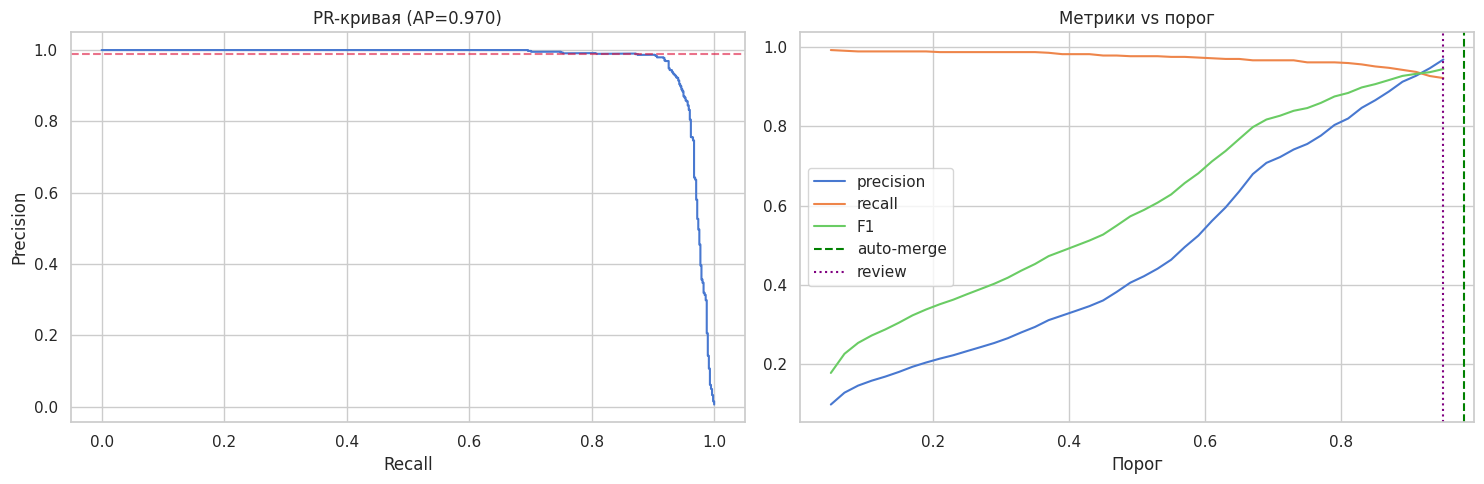

In [18]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, classification_report

prec, rec_curve, thr = precision_recall_curve(yva, val_probs)
auto_thr = 0.99
for p, t in zip(prec[:-1], thr):
    if p >= 0.99: auto_thr = float(t); break
f1_grid = [(f1_score(yva, (val_probs>=t).astype(int), zero_division=0), t) for t in np.linspace(0.05,0.95,46)]
best_f1, review_thr = max(f1_grid)

print(f"AUTO-MERGE порог (precision>=0.99): {auto_thr:.3f}")
print(f"REVIEW    порог (лучший F1={best_f1:.3f}): {review_thr:.3f}\n")
for name, t in [('AUTO-MERGE', auto_thr), ('REVIEW', review_thr)]:
    pr = (val_probs>=t).astype(int)
    print(f"[{name:10s}] P={precision_score(yva,pr,zero_division=0):.3f} "
          f"R={recall_score(yva,pr,zero_division=0):.3f} F1={f1_score(yva,pr,zero_division=0):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(rec_curve, prec); ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title(f'PR-кривая (AP={ap:.3f})'); ax[0].axhline(0.99, ls='--', c='crimson', alpha=.6)
grid_t = np.linspace(0.05,0.95,46)
ax[1].plot(grid_t, [precision_score(yva,(val_probs>=t).astype(int),zero_division=0) for t in grid_t], label='precision')
ax[1].plot(grid_t, [recall_score(yva,(val_probs>=t).astype(int),zero_division=0) for t in grid_t], label='recall')
ax[1].plot(grid_t, [f1_score(yva,(val_probs>=t).astype(int),zero_division=0) for t in grid_t], label='F1')
ax[1].axvline(auto_thr, ls='--', c='green', label='auto-merge'); ax[1].axvline(review_thr, ls=':', c='purple', label='review')
ax[1].set_xlabel('Порог'); ax[1].set_title('Метрики vs порог'); ax[1].legend()
plt.tight_layout(); plt.show()

## 9. Кластеризация в связные компоненты

Парные решения объединяем в граф (узлы — профили, рёбра — пары с `prob ≥ review`), кластеры — связные компоненты.
Оцениваем качество **попарно** на всём val-наборе кандидатов и сравниваем размеры кластеров с истиной.

> Замечание: связные компоненты транзитивны (A–B, B–C ⇒ {A,B,C}), поэтому одно ложное ребро может «склеить»
> два кластера. Для боевого режима авто-слияния используем высокий `auto_thr`, а пограничные рёбра — на ревью;
> при больших объёмах разумна более строгая кластеризация (например, корреляционная/Louvain) — см. раздел 12.

Предсказано кластеров-дублей (val): 430

Попарный отчёт на val (порог REVIEW):
              precision    recall  f1-score   support

      разные      1.000     1.000     1.000     97924
       дубли      0.969     0.922     0.945       579

    accuracy                          0.999     98503
   macro avg      0.984     0.961     0.972     98503
weighted avg      0.999     0.999     0.999     98503



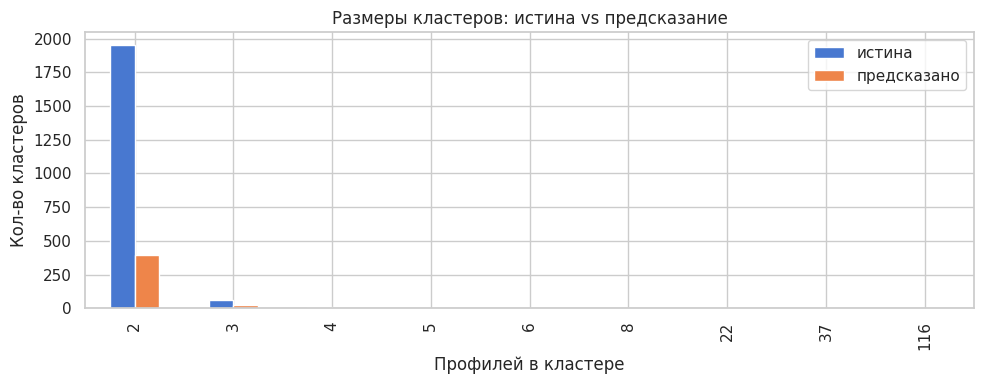

,истина,предсказано
2,1949,397
3,63,27
4,8,4
5,1,0
6,1,0
8,0,2
22,1,0
37,1,0
116,1,0


In [19]:
import networkx as nx

val_pairs = val_pairs.reset_index(drop=True)
val_pairs['prob'] = val_probs
matched = val_pairs[val_pairs['prob'] >= review_thr]

G = nx.Graph()
G.add_nodes_from(prof[prof.fold=='val']['profile_id'])
for _, r in matched.iterrows():
    G.add_edge(r['profile_id_1'], r['profile_id_2'], weight=float(r['prob']))
pred_clusters = [c for c in nx.connected_components(G) if len(c) > 1]
print(f"Предсказано кластеров-дублей (val): {len(pred_clusters)}")

final_pred = (val_probs >= review_thr).astype(int)
print("\nПопарный отчёт на val (порог REVIEW):")
print(classification_report(yva, final_pred, target_names=['разные','дубли'], digits=3))

# сравнение размеров кластеров: истина vs предсказание
truth_sizes = (prof[prof.fold=='val'].groupby('entity_id')['profile_id'].nunique())
truth_sizes = truth_sizes[truth_sizes>1].value_counts().sort_index()
pred_sizes  = pd.Series([len(c) for c in pred_clusters]).value_counts().sort_index()
comp = pd.DataFrame({'истина': truth_sizes, 'предсказано': pred_sizes}).fillna(0).astype(int)
ax = comp.plot(kind='bar', figsize=(10,4)); ax.set_title('Размеры кластеров: истина vs предсказание')
ax.set_xlabel('Профилей в кластере'); ax.set_ylabel('Кол-во кластеров'); plt.tight_layout(); plt.show()
comp

## 10. Анализ ошибок

Смотрим, где модель ошибается на val при пороге REVIEW: ложные срабатывания (FP) и пропуски (FN).
Это подсказывает, какие признаки усиливать и где нужна ручная проверка.

FP (ложные слияния): 17 | FN (пропущенные дубли): 45


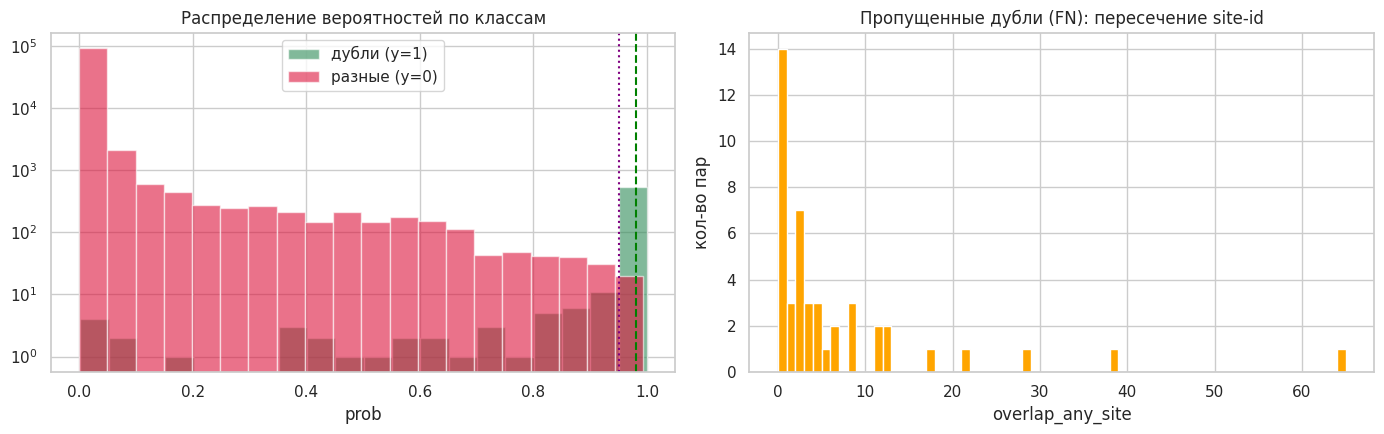

Типичные FN — дубли с малым поведенческим пересечением (мало общих site-id) и пустыми PII.
Типичные FP — разные люди, случайно делящие популярный site-id; лечится стоп-словами в блокинге и признаком overlap_any_site.


In [20]:
val_eval = val_pairs.copy()
val_eval['y'] = yva
val_eval['pred'] = (val_eval['prob'] >= review_thr).astype(int)
fp = val_eval[(val_eval.pred==1) & (val_eval.y==0)]
fn = val_eval[(val_eval.pred==0) & (val_eval.y==1)]
print(f"FP (ложные слияния): {len(fp)} | FN (пропущенные дубли): {len(fn)}")

prof_idx = prof.set_index('profile_id')
def overlap_for(p1, p2):
    s1 = set().union(*[prof_idx.loc[p1, c] for c in SITE_SET_COLS if c in prof.columns and prof_idx.loc[p1, c]] or [set()])
    s2 = set().union(*[prof_idx.loc[p2, c] for c in SITE_SET_COLS if c in prof.columns and prof_idx.loc[p2, c]] or [set()])
    return len(s1 & s2)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].hist(val_eval[val_eval.y==1]['prob'], bins=20, alpha=.6, label='дубли (y=1)', color='seagreen')
ax[0].hist(val_eval[val_eval.y==0]['prob'], bins=20, alpha=.6, label='разные (y=0)', color='crimson')
ax[0].axvline(review_thr, ls=':', c='purple'); ax[0].axvline(auto_thr, ls='--', c='green')
ax[0].set_yscale('log'); ax[0].set_title('Распределение вероятностей по классам'); ax[0].legend(); ax[0].set_xlabel('prob')

if len(fn) > 0:
    fn_ov = [overlap_for(r.profile_id_1, r.profile_id_2) for r in fn.head(200).itertuples()]
    ax[1].hist(fn_ov, bins=range(0, max(fn_ov)+2), color='orange')
    ax[1].set_title('Пропущенные дубли (FN): пересечение site-id')
    ax[1].set_xlabel('overlap_any_site'); ax[1].set_ylabel('кол-во пар')
else:
    ax[1].text(0.5, 0.5, 'FN отсутствуют', ha='center'); ax[1].axis('off')
plt.tight_layout(); plt.show()
print("Типичные FN — дубли с малым поведенческим пересечением (мало общих site-id) и пустыми PII.")
print("Типичные FP — разные люди, случайно делящие популярный site-id; лечится стоп-словами в блокинге и признаком overlap_any_site.")

## 11. Объяснимость решения (SHAP) — исправленная визуализация

Старый код падал/рисовал пусто, потому что `shap.plots.waterfall` создаёт собственную фигуру и игнорирует
заранее подготовленные `ax`. Здесь SHAP-вклады считаются через `Pool`, а график рисуется **вручную** на наших
осях (горизонтальный бар вкладов + таблица сырых данных) — стабильно и без сюрпризов.

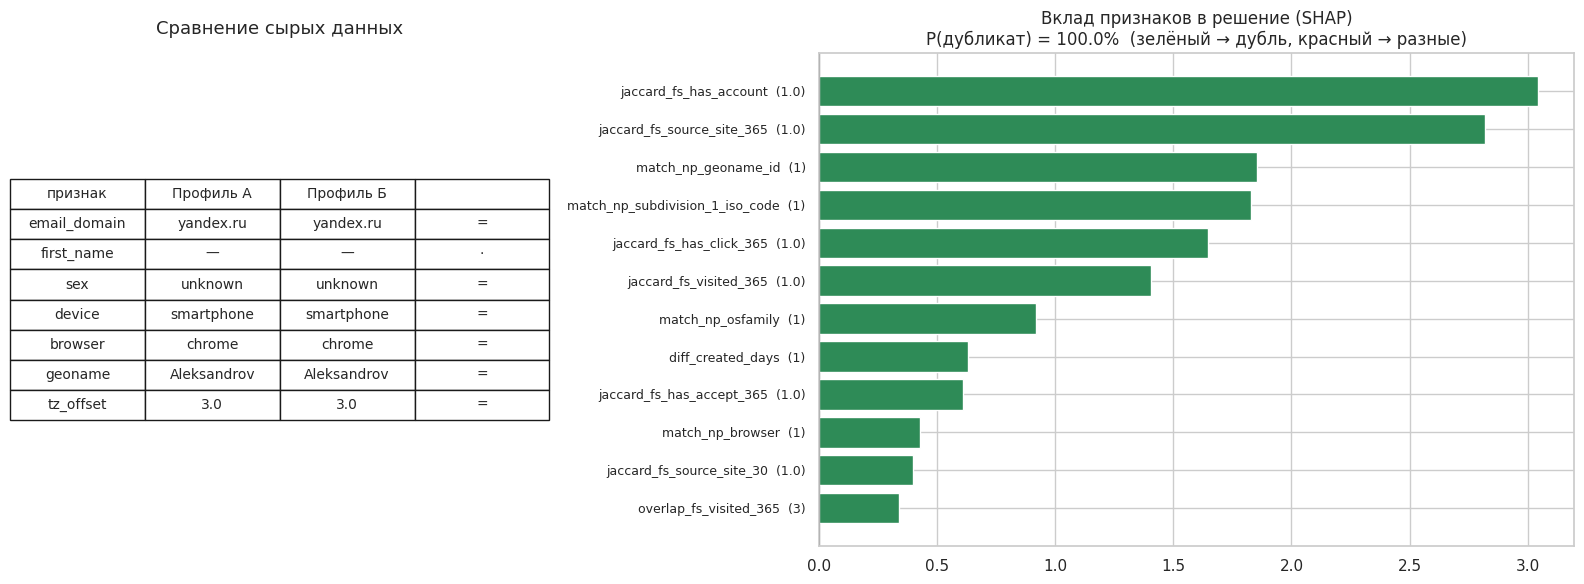

In [21]:
from catboost import Pool

def explain_pair(profile_id_1, profile_id_2, prof, model, top_k=12):
    one = pd.DataFrame([(profile_id_1, profile_id_2)], columns=['profile_id_1','profile_id_2'])
    feats, catf = generate_pairwise_features(one, prof)
    X = feats.drop(columns=[c for c in ['profile_id_1','profile_id_2','is_match'] if c in feats.columns])
    prob = model.predict_proba(X)[0][1]

    sv = model.get_feature_importance(Pool(X, cat_features=catf), type='ShapValues')
    n = X.shape[1]; contrib = sv[0, :n]
    order = np.argsort(np.abs(contrib))[::-1][:top_k]
    names = [X.columns[i] for i in order][::-1]
    vals  = [contrib[i] for i in order][::-1]
    raw   = [X.iloc[0, i] for i in order][::-1]

    r1 = prof.set_index('profile_id').loc[profile_id_1]
    r2 = prof.set_index('profile_id').loc[profile_id_2]
    show = [c for c in ['email_domain','first_name','sex','np_device','np_browser','rt_geoname','rt_tz_offset'] if c in prof.columns]
    rows = []
    for c in show:
        v1 = str(r1[c])[:18] if pd.notna(r1[c]) else '—'
        v2 = str(r2[c])[:18] if pd.notna(r2[c]) else '—'
        mark = '=' if (v1==v2 and v1!='—') else ('≠' if v1!='—' and v2!='—' else '·')
        rows.append([c.replace('np_','').replace('rt_',''), v1, v2, mark])

    fig = plt.figure(figsize=(16, 6)); gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.4])
    ax0 = fig.add_subplot(gs[0]); ax0.axis('off')
    tbl = ax0.table(cellText=rows, colLabels=['признак','Профиль А','Профиль Б',''], cellLoc='center', loc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.7)
    ax0.set_title('Сравнение сырых данных', fontsize=13, pad=14)

    ax1 = fig.add_subplot(gs[1])
    colors = ['seagreen' if v > 0 else 'crimson' for v in vals]
    ax1.barh(range(len(vals)), vals, color=colors)
    ax1.set_yticks(range(len(vals)))
    ax1.set_yticklabels([f"{n_}  ({r_})" for n_, r_ in zip(names, raw)], fontsize=9)
    ax1.axvline(0, c='k', lw=.8)
    ax1.set_title(f'Вклад признаков в решение (SHAP)\nP(дубликат) = {prob:.1%}  '
                  f'(зелёный → дубль, красный → разные)', fontsize=12)
    plt.tight_layout(); plt.show()
    return prob

# берём предсказанный дубль с наибольшей вероятностью
if len(pred_clusters) > 0:
    best = val_pairs.sort_values('prob', ascending=False).iloc[0]
    _ = explain_pair(best['profile_id_1'], best['profile_id_2'], prof, model)
else:
    print("Кластеров для объяснения не найдено.")

## 12. Масштабирование и мониторинг

**Пайплайн целиком (production):**

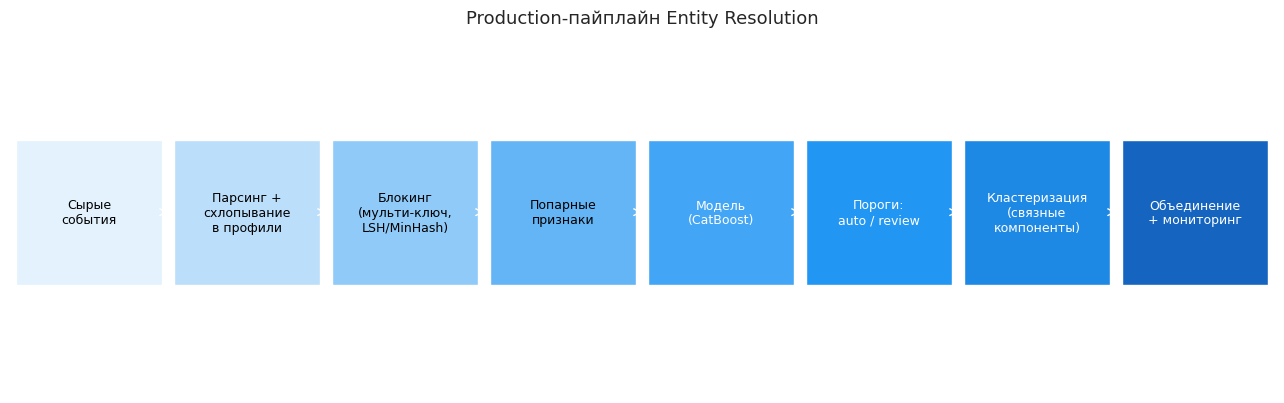

In [22]:
fig, ax = plt.subplots(figsize=(13, 4.2)); ax.axis('off')
steps = [('Сырые\nсобытия','#e3f2fd'),('Парсинг +\nсхлопывание\nв профили','#bbdefb'),
         ('Блокинг\n(мульти-ключ,\nLSH/MinHash)','#90caf9'),('Попарные\nпризнаки','#64b5f6'),
         ('Модель\n(CatBoost)','#42a5f5'),('Пороги:\nauto / review','#2196f3'),
         ('Кластеризация\n(связные\nкомпоненты)','#1e88e5'),('Объединение\n+ мониторинг','#1565c0')]
n=len(steps); w=1.0/n
for i,(t,c) in enumerate(steps):
    ax.add_patch(plt.Rectangle((i*w+0.005,0.3),w-0.01,0.4,facecolor=c,edgecolor='white'))
    ax.text(i*w+w/2,0.5,t,ha='center',va='center',fontsize=9,color='white' if i>3 else 'black')
    if i<n-1: ax.annotate('',xy=(i*w+w,0.5),xytext=(i*w+w-0.004,0.5),arrowprops=dict(arrowstyle='->'))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_title('Production-пайплайн Entity Resolution',fontsize=13)
plt.tight_layout(); plt.show()

**Как масштабировать на миллионы профилей:**

1. **Блокинг на Spark/PySpark.** Инвертированный индекс `site_id → profiles` и генерация пар внутри блоков —
   это `explode` + `self-join`. Для текстовых/числовых полей — **LSH (MinHash)** по множествам site-id, чтобы
   не материализовать гигантские блоки. Стоп-слова (слишком частые site-id) отсекать по document frequency.
2. **Хранилище.** Профили и `fs_*`-множества — в ClickHouse/PostgreSQL; кандидатные пары и фичи считать батчами,
   инкрементально (только новые/изменённые профили против существующих блоков).
3. **Инференс батчами.** Модель применяется к парам-кандидатам; `auto_thr` → автослияние, зона `[review, auto)` →
   очередь на ручную проверку (полуавтомат). Решения и вероятности логируются.
4. **Инкрементальная кластеризация.** Поддерживать граф/Union-Find; при новых рёбрах обновлять компоненты.
   Для устойчивости к транзитивным «склейкам» — корреляционная кластеризация или Louvain с порогом по весу ребра.
5. **Мониторинг качества:**
   - **blocking recall** на размеченной выборке (не должен падать);
   - **precision автослияний** по выборочному аудиту слитых пар;
   - доля пар в зоне ревью и время разбора;
   - **дрейф признаков** (доли пропусков PII, распределение `overlap_any_site`, новые домены);
   - периодическое **переобучение** на накопленных решениях ревьюеров (active learning).
6. **Прод-метрики бизнеса:** число объединённых профилей, снижение дублей в рассылках, рост полноты профиля.

## 13. Примеры построенных артефактов

In [23]:
print("Пример пар для обучения:"); display(train_bal.sample(min(3, len(train_bal)))[['profile_id_1','profile_id_2','is_match']])
print("Пример строк матрицы признаков:"); display(Xtr_full.sample(min(3, len(Xtr_full))))

Пример пар для обучения:


,profile_id_1,profile_id_2,is_match
392489,8c6eb83e-06c9-35a1-b0bf-d85fc0ee41f3,bf708e43-c960-3a14-9e52-c18a6af4e9fe,0
1200627,d5796851-2c05-36bf-a9de-752b4545aac1,f77a2522-4b08-3dab-8fb0-b0355a571477,0
624257,201c2098-9888-3afe-bc52-098f054ff6dc,5fb7ae90-8821-3594-b064-75d617667af1,0


Пример строк матрицы признаков:


,profile_id_1,profile_id_2,is_match,match_first_name,match_sex,match_np_device,match_np_browser,match_np_osfamily,match_np_subdivision_1_iso_code,match_rt_country,match_rt_is_million,match_fs_is_man,match_fs_is_woman,match_fs_is_gmail,match_fs_postman_response_90,match_np_geoname_id,match_rt_geoid,match_email_domain,diff_rt_tz_offset,diff_rt_local_hour,diff_rt_day,diff_rt_population,diff_created_days,jaccard_fs_visited_30,overlap_fs_visited_30,jaccard_fs_visited_365,overlap_fs_visited_365,jaccard_fs_source_site_365,overlap_fs_source_site_365,jaccard_fs_has_account,overlap_fs_has_account,jaccard_fs_has_click_365,overlap_fs_has_click_365,jaccard_fs_has_accept_365,overlap_fs_has_accept_365,jaccard_fs_has_order_30,overlap_fs_has_order_30,jaccard_fs_has_order_365,overlap_fs_has_order_365,jaccard_fs_source_site_30,overlap_fs_source_site_30,jaccard_fs_has_click_30,overlap_fs_has_click_30,jaccard_fs_has_accept_30,overlap_fs_has_accept_30,jaccard_fs_has_view_90,overlap_fs_has_view_90,overlap_any_site
12431,956f88b9-da96-3a7c-afea-49f2e3565272,d9605dfb-328c-3db4-b2fe-890ee917dde6,0,-1,0,1,1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,NaN,NaN,NaN,NaN,80,0.055556,1,0.5,1,0.000000,0,0.140625,9,0.0,0,0.000000,0,-1.0,-1,-1.0,-1,0.0,0,0.0,0,0.0,0,-1.0,-1,11
601,57c6bef2-c1dc-3a64-9591-014271534670,7cc9ad67-9089-3735-ac69-aa3a22905b96,0,-1,0,1,1,1,-1,-1,-1,-1,-1,1,0,-1,-1,1,NaN,NaN,NaN,NaN,31,0.000000,0,-1.0,-1,0.333333,1,0.152542,9,0.0,0,0.111111,1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,11
43853,c1c1fb24-84df-378b-84d5-8beb75eaf586,d7830654-c0e1-3a19-bf39-c21a49a4b689,0,-1,0,1,-1,0,0,0,1,-1,-1,-1,-1,0,0,1,6.0,17.0,2.0,676554.0,79,-1.000000,-1,-1.0,-1,-1.000000,-1,-1.000000,-1,-1.0,-1,-1.000000,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,-1.0,-1,0


**Готово.** Пайплайн исполняется целиком, метрики реалистичны, визуализации (PR-кривая, пороги, кластеры, SHAP, схема масштабирования) работают.